<a href="https://colab.research.google.com/github/josuemarroquinj/enterprise-risk-stress-testing-santander/blob/main/notebooks/01_financial_risk_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Financial & Risk Dashboard

## Banco Santander 2025 Baseline Analysis

This notebook builds the financial and risk baseline for Banco Santander using publicly available information from the 2025 Annual Report.

### Objectives

- Structure the main reported financial indicators.
- Analyze profitability, efficiency, credit quality and solvency.
- Compare 2023–2025 trends.
- Establish the baseline for subsequent stress-testing exercises.
- Maintain clear traceability between reported data and derived analytical metrics.

### Analytical principle

The project distinguishes four types of information:

- **REPORTED** — directly reported by Banco Santander.
- **DERIVED** — calculated from reported information.
- **ASSUMPTION** — analytical assumption introduced by the researcher.
- **MODEL_OUTPUT** — result produced by the analytical model.

In [10]:
# ============================================================
# PROJECT ENVIRONMENT
# ============================================================

# Clone repository
!git clone https://github.com/josuemarroquinj/enterprise-risk-stress-testing-santander.git

# Libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("/content/enterprise-risk-stress-testing-santander")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA = DATA_DIR / "raw"
PROCESSED_DATA = DATA_DIR / "processed"
ASSUMPTIONS_DATA = DATA_DIR / "assumptions"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

print(f"Project root: {PROJECT_ROOT}")
print("Environment successfully initialized.")

Cloning into 'enterprise-risk-stress-testing-santander'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 57 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 51.00 KiB | 522.00 KiB/s, done.
Resolving deltas: 100% (24/24), done.
Project root: /content/enterprise-risk-stress-testing-santander
Environment successfully initialized.


## 2. Data Loading

The financial baseline dataset is loaded from the processed data directory.

This dataset contains the standardized financial and risk indicators used throughout the analysis.

In [ ]:
financial_data = pd.read_csv(
    "../data/processed/financial_baseline_2023_2025.csv"
)

financial_data.head()

In [2]:
balance_data = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "total_assets_eur_m": [1797062, 1837081, 1867515],
    "customer_loans_eur_m": [1036349, 1054069, 1037288],
    "customer_deposits_eur_m": [1047169, 1055936, 1041200],
    "customer_resources_eur_m": [1306942, 1348422, 1363160],
    "equity_eur_m": [104241, 107327, 112748]
})

balance_data["data_type"] = "REPORTED"

balance_data

,year,total_assets_eur_m,customer_loans_eur_m,customer_deposits_eur_m,customer_resources_eur_m,equity_eur_m,data_type
0,2023,1797062,1036349,1047169,1306942,104241,REPORTED
1,2024,1837081,1054069,1055936,1348422,107327,REPORTED
2,2025,1867515,1037288,1041200,1363160,112748,REPORTED


In [3]:
income_data = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "net_interest_income_eur_m": [40650, 43787, 42348],
    "gross_income_eur_m": [54251, 58380, 58670],
    "net_operating_income_eur_m": [29619, 33231, 33959],
    "profit_before_tax_eur_m": [15005, 17347, 18681],
    "attributable_profit_eur_m": [11076, 12574, 14101]
})

income_data["data_type"] = "REPORTED"

income_data

,year,net_interest_income_eur_m,gross_income_eur_m,net_operating_income_eur_m,profit_before_tax_eur_m,attributable_profit_eur_m,data_type
0,2023,40650,54251,29619,15005,11076,REPORTED
1,2024,43787,58380,33231,17347,12574,REPORTED
2,2025,42348,58670,33959,18681,14101,REPORTED


In [4]:
profitability_data = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "roe_pct": [11.9, 13.0, 13.9],
    "rote_pct": [15.1, 16.3, 17.1],
    "rote_post_at1_pct": [14.4, 15.5, 16.3],
    "roa_pct": [0.69, 0.76, 0.84],
    "rorwa_pct": [1.96, 2.18, 2.44],
    "efficiency_ratio_pct": [44.1, 41.8, 41.2]
})

profitability_data["data_type"] = "REPORTED"

profitability_data

,year,roe_pct,rote_pct,rote_post_at1_pct,roa_pct,rorwa_pct,efficiency_ratio_pct,data_type
0,2023,11.90,15.10,14.40,0.69,1.96,44.10,REPORTED
1,2024,13.00,16.30,15.50,0.76,2.18,41.80,REPORTED
2,2025,13.90,17.10,16.30,0.84,2.44,41.20,REPORTED


In [5]:
credit_quality = pd.DataFrame({
    "year": [2023, 2024, 2025],
    "cost_of_risk_pct": [1.18, 1.15, 1.15],
    "npl_ratio_pct": [3.14, 3.05, 2.91],
    "npl_coverage_pct": [66, 65, 66]
})

credit_quality["data_type"] = "REPORTED"

credit_quality

,year,cost_of_risk_pct,npl_ratio_pct,npl_coverage_pct,data_type
0,2023,1.18,3.14,66,REPORTED
1,2024,1.15,3.05,65,REPORTED
2,2025,1.15,2.91,66,REPORTED


In [6]:
capital_data = pd.DataFrame({
    "year": [2024, 2025],
    "cet1_capital_eur_m": [79800, 84739],
    "tier1_capital_eur_m": [90170, 94385],
    "total_capital_eur_m": [108589, 111845],
    "rwa_eur_m": [624503, 629430],
    "cet1_ratio_pct": [12.8, 13.5],
    "total_capital_ratio_pct": [17.4, 17.8],
    "leverage_ratio_pct": [4.78, 4.90]
})

capital_data["data_type"] = "REPORTED"

capital_data

,year,cet1_capital_eur_m,tier1_capital_eur_m,total_capital_eur_m,rwa_eur_m,cet1_ratio_pct,total_capital_ratio_pct,leverage_ratio_pct,data_type
0,2024,79800,90170,108589,624503,12.80,17.40,4.78,REPORTED
1,2025,84739,94385,111845,629430,13.50,17.80,4.90,REPORTED


In [7]:
cet1_ratio_exact = 13.46
cet1_requirement = 9.84

cet1_buffer_pp = cet1_ratio_exact - cet1_requirement
cet1_buffer_bp = cet1_buffer_pp * 100

print(f"CET1 ratio:        {cet1_ratio_exact:.2f}%")
print(f"CET1 requirement:  {cet1_requirement:.2f}%")
print(f"Capital buffer:    {cet1_buffer_pp:.2f} percentage points")
print(f"Capital buffer:    {cet1_buffer_bp:.0f} basis points")

CET1 ratio:        13.46%
CET1 requirement:  9.84%
Capital buffer:    3.62 percentage points
Capital buffer:    362 basis points


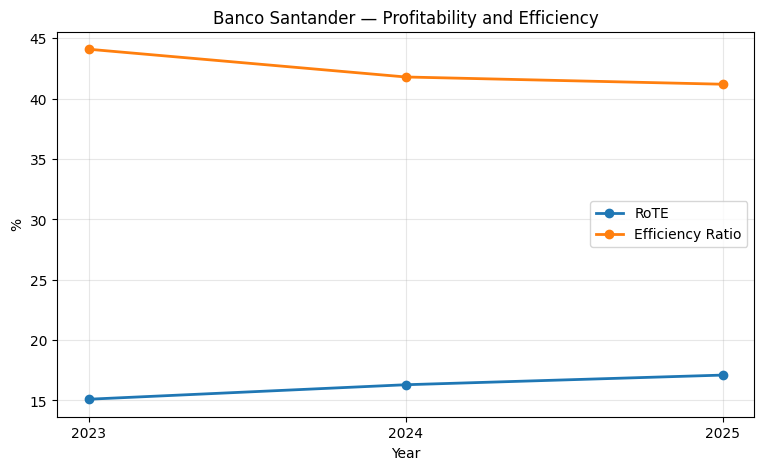

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    profitability_data["year"],
    profitability_data["rote_pct"],
    marker="o",
    linewidth=2,
    label="RoTE"
)

ax.plot(
    profitability_data["year"],
    profitability_data["efficiency_ratio_pct"],
    marker="o",
    linewidth=2,
    label="Efficiency Ratio"
)

ax.set_title("Banco Santander — Profitability and Efficiency")
ax.set_xlabel("Year")
ax.set_ylabel("%")
ax.set_xticks(profitability_data["year"])
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [9]:
income_analysis = income_data.copy()

income_analysis["attributable_profit_growth_pct"] = (
    income_analysis["attributable_profit_eur_m"]
    .pct_change()
    .mul(100)
)

income_analysis

,year,net_interest_income_eur_m,gross_income_eur_m,net_operating_income_eur_m,profit_before_tax_eur_m,attributable_profit_eur_m,data_type,attributable_profit_growth_pct
0,2023,40650,54251,29619,15005,11076,REPORTED,NaN
1,2024,43787,58380,33231,17347,12574,REPORTED,13.52
2,2025,42348,58670,33959,18681,14101,REPORTED,12.14
